In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
d=pd.read_csv("myn.csv")

C:\Users\sanju\AppData\Local\Temp\ipykernel_16436\1129075072.py:1: DtypeWarning: Columns (0: DiscountOffer) have mixed types. Specify dtype option on import or set low_memory=False.
  d=pd.read_csv("myn.csv")


In [4]:
d.shape

(526564, 13)

In [5]:
d.head()

,URL,Product_id,BrandName,Category,Individual_category,category_by_Gender,Description,DiscountPrice (in Rs),OriginalPrice (in Rs),DiscountOffer,SizeOption,Ratings,Reviews
0,https://www.myntra.com/jeans/roadster/roadster...,2296012,Roadster,Bottom Wear,jeans,Men,roadster men navy blue slim fit mid rise clean...,824.0,1499.0,45% OFF,"28, 30, 32, 34, 36",3.9,999.0
1,https://www.myntra.com/track-pants/locomotive/...,13780156,LOCOMOTIVE,Bottom Wear,track-pants,Men,locomotive men black white solid slim fit tra...,517.0,1149.0,55% OFF,"S, M, L, XL",4.0,999.0
2,https://www.myntra.com/shirts/roadster/roadste...,11895958,Roadster,Topwear,shirts,Men,roadster men navy white black geometric print...,629.0,1399.0,55% OFF,"38, 40, 42, 44, 46, 48",4.3,999.0
3,https://www.myntra.com/shapewear/zivame/zivame...,4335679,Zivame,Lingerie & Sleep Wear,shapewear,Women,zivame women black saree shapewear zi3023core0...,893.0,1295.0,31% OFF,"S, M, L, XL, XXL",4.2,999.0
4,https://www.myntra.com/tshirts/roadster/roadst...,11690882,Roadster,Western,tshirts,Women,roadster women white solid v neck pure cotton ...,NaN,599.0,35% OFF,"XS, S, M, L, XL",4.2,999.0


In [6]:
d.dtypes

URL                          str
Product_id                 int64
BrandName                    str
Category                     str
Individual_category          str
category_by_Gender           str
Description                  str
DiscountPrice (in Rs)    float64
OriginalPrice (in Rs)    float64
DiscountOffer                str
SizeOption                   str
Ratings                  float64
Reviews                  float64
dtype: object

In [8]:
d.isnull().sum()

URL                           0
Product_id                    0
BrandName                     0
Category                      0
Individual_category           0
category_by_Gender            0
Description                   0
DiscountPrice (in Rs)    193158
OriginalPrice (in Rs)         0
DiscountOffer             74306
SizeOption                    0
Ratings                  336152
Reviews                  336152
dtype: int64

In [9]:
d.describe()

,Product_id,DiscountPrice (in Rs),OriginalPrice (in Rs),Ratings,Reviews
count,5.265640e+05,333406.000000,526564.000000,190412.000000,190412.000000
mean,1.506939e+07,1237.444401,2414.068615,4.094892,61.990820
std,3.225710e+06,1052.063517,1916.962914,0.494158,125.714537
min,2.739900e+04,127.000000,99.000000,1.000000,0.000000
25%,1.388053e+07,659.000000,1299.000000,3.900000,8.000000
50%,1.597106e+07,952.000000,1999.000000,4.200000,18.000000
75%,1.734741e+07,1469.000000,2899.000000,4.400000,52.000000
max,1.846435e+07,27996.000000,90000.000000,5.000000,999.000000


In [10]:
d.rename(columns={
    'DiscountPrice (in Rs)': 'DiscountPrice',
    'OriginalPrice (in Rs)': 'OriginalPrice'
}, inplace=True)

In [12]:
d.dropna(subset=['DiscountPrice', 'Ratings', 'Reviews'], inplace=True)

In [13]:
d.shape

(117565, 13)

In [14]:
d['DiscountPercent'] = ((d['OriginalPrice'] - d['DiscountPrice']) / d['OriginalPrice']) * 100
d['DiscountPercent'] = d['DiscountPercent'].round(2)

In [16]:
d['Revenue'] = d['DiscountPrice'] * d['Reviews']

print(d[['BrandName', 'DiscountPrice', 'Reviews', 'Revenue']].head())

    BrandName  DiscountPrice  Reviews   Revenue
0    Roadster          824.0    999.0  823176.0
1  LOCOMOTIVE          517.0    999.0  516483.0
2    Roadster          629.0    999.0  628371.0
3      Zivame          893.0    999.0  892107.0
6  HIGHLANDER          599.0    998.0  597802.0


In [18]:
print(d.isnull().sum())

URL                     0
Product_id              0
BrandName               0
Category                0
Individual_category     0
category_by_Gender      0
Description             0
DiscountPrice           0
OriginalPrice           0
DiscountOffer          24
SizeOption              0
Ratings                 0
Reviews                 0
DiscountPercent         0
Revenue                 0
dtype: int64


In [ ]:
d.shape


(117565, 15)

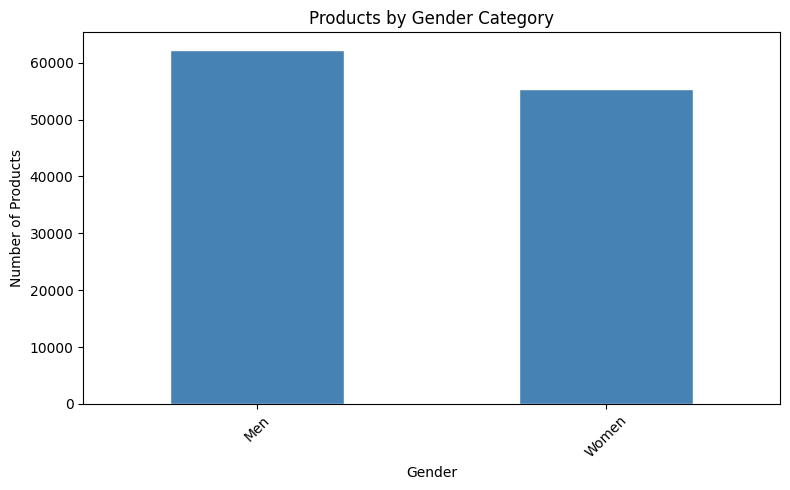

In [21]:
plt.figure(figsize=(8,5))
d['category_by_Gender'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Products by Gender Category')
plt.xlabel('Gender')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('outputs/gender_distribution.png')
plt.show()

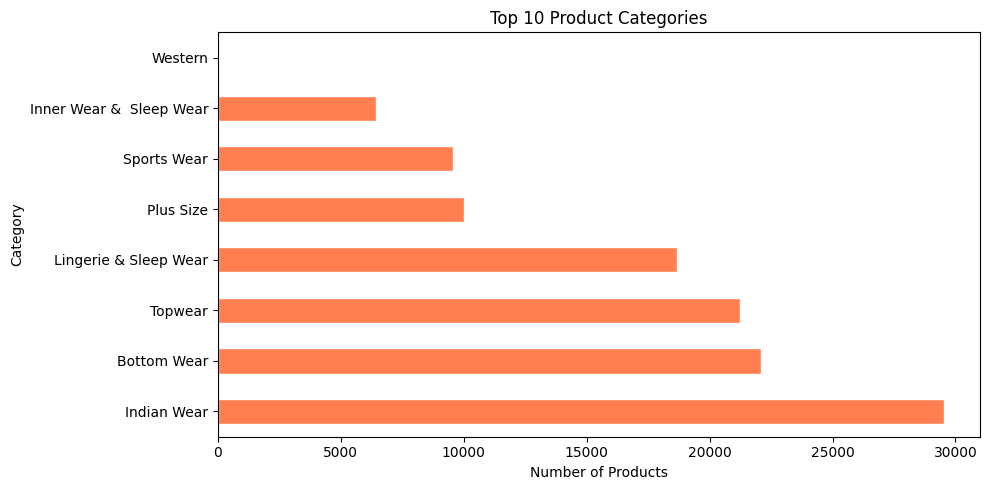

In [23]:
plt.figure(figsize=(10,5))
d['Category'].value_counts().head(10).plot(kind='barh', color='coral', edgecolor='white')
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Products')
plt.tight_layout()
# plt.savefig('outputs/category_distribution.png')
plt.show()

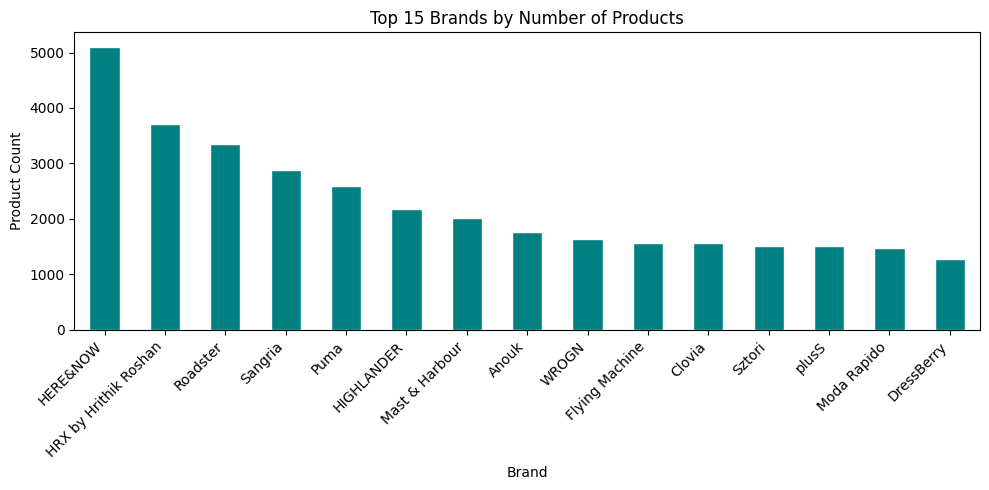

In [24]:
plt.figure(figsize=(10,5))
d['BrandName'].value_counts().head(15).plot(kind='bar', color='teal', edgecolor='white')
plt.title('Top 15 Brands by Number of Products')
plt.xlabel('Brand')
plt.ylabel('Product Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('outputs/top_brands_count.png')
plt.show()

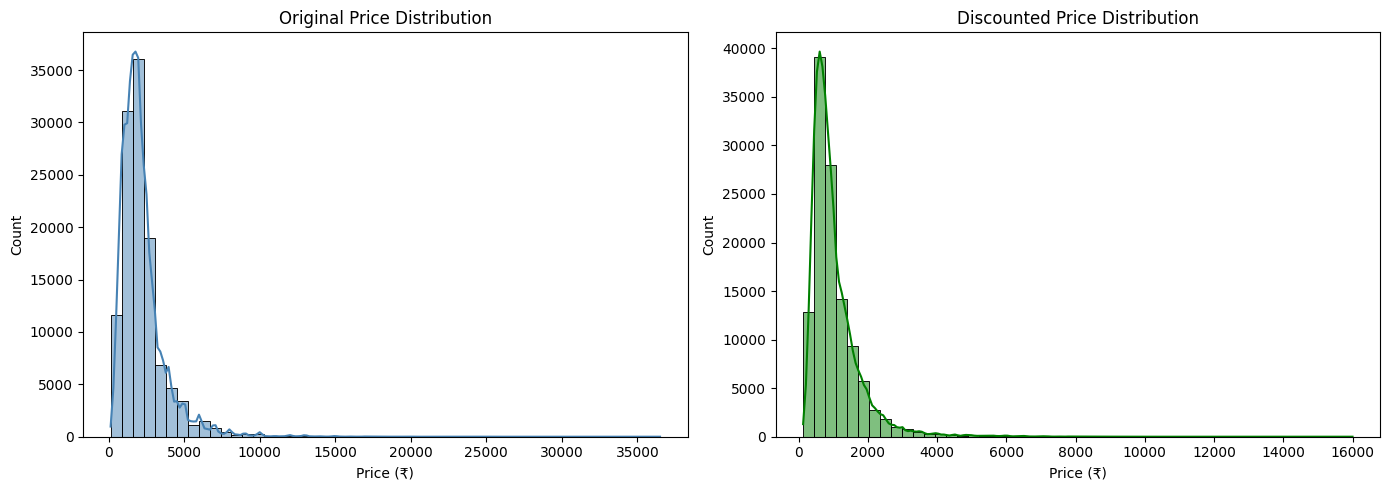

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(d['OriginalPrice'], bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Original Price Distribution')
axes[0].set_xlabel('Price (₹)')

sns.histplot(d['DiscountPrice'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title('Discounted Price Distribution')
axes[1].set_xlabel('Price (₹)')

plt.tight_layout()
# plt.savefig('outputs/price_distribution.png')
plt.show()

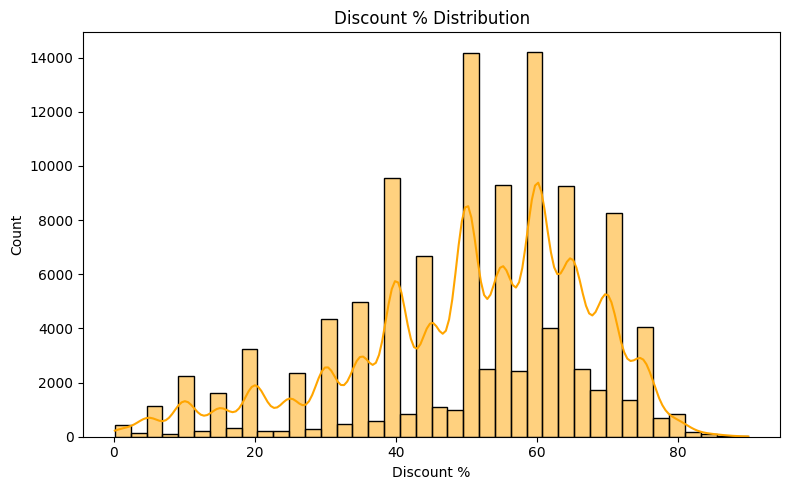

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(d['DiscountPercent'], bins=40, color='orange', kde=True)
plt.title('Discount % Distribution')
plt.xlabel('Discount %')
plt.tight_layout()
# plt.savefig('outputs/discount_distribution.png')
plt.show()

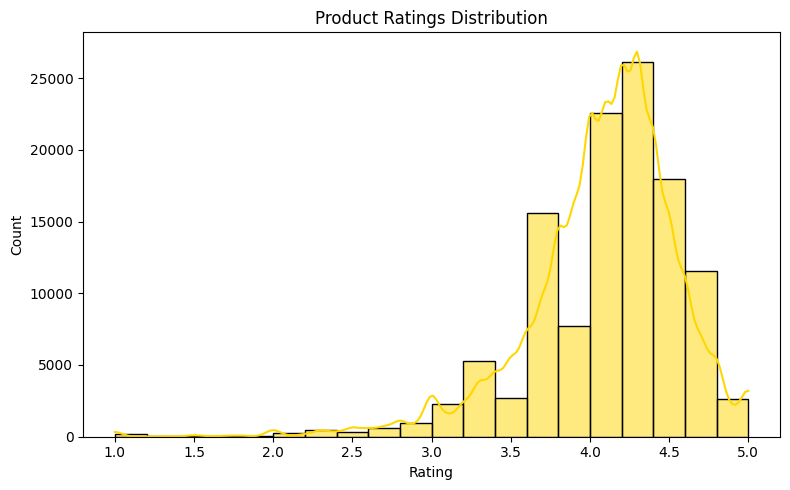

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(d['Ratings'], bins=20, color='gold', kde=True)
plt.title('Product Ratings Distribution')
plt.xlabel('Rating')
plt.tight_layout()
# plt.savefig('outputs/ratings_distribution.png')
plt.show()

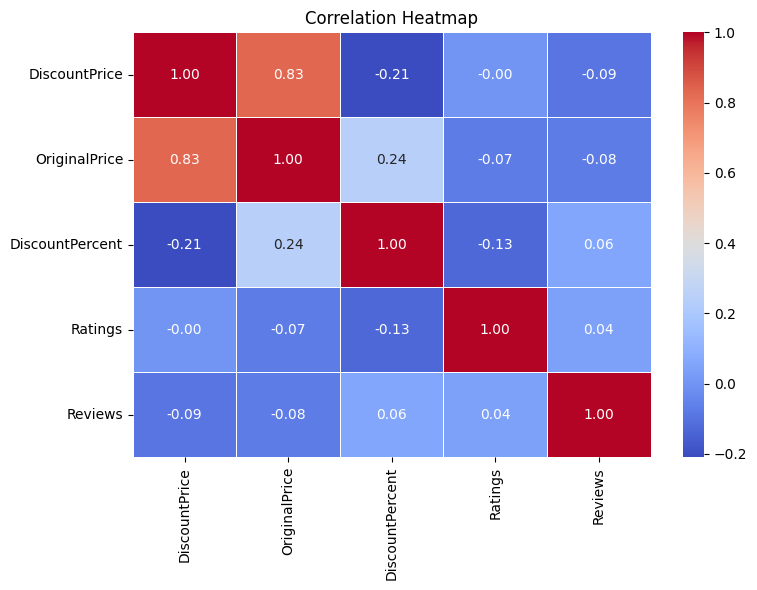

In [28]:
plt.figure(figsize=(8,6))
cols = ['DiscountPrice', 'OriginalPrice', 'DiscountPercent', 'Ratings', 'Reviews']
sns.heatmap(d[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
# plt.savefig('outputs/heatmap.png')
plt.show()

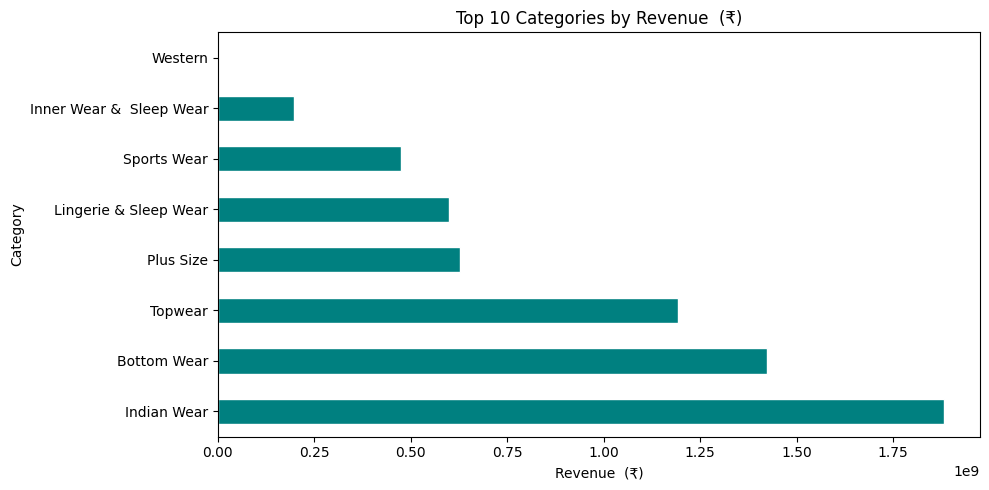

In [29]:
plt.figure(figsize=(10,5))
d.groupby('Category')['Revenue'].sum().nlargest(10)\
  .plot(kind='barh', color='teal', edgecolor='white')
plt.title('Top 10 Categories by Revenue  (₹)')
plt.xlabel('Revenue  (₹)')
plt.tight_layout()
# plt.savefig('outputs/top_categories_revenue.png')
plt.show()

In [32]:
# Find top category
top_category = d.groupby('Category')['Reviews'].sum().idxmax()
print(f"Top Category: {top_category}")

# Filter for that category
top_cat = d[d['Category'] == top_category]

# Top brand in that category
top_brand = top_cat.groupby('BrandName')['Reviews'].sum().idxmax()
print(f"Top Brand in {top_category}: {top_brand}")

# Revenue proxy for that category
total_revenue = top_cat['Revenue'].sum()
print(f"Revenue  for {top_category}: ₹{total_revenue:,.0f}")

Top Category: Indian Wear
Top Brand in Indian Wear: Anouk
Revenue  for Indian Wear: ₹1,880,937,518


In [33]:
# Minimum 50 reviews to filter out products with very few ratings
top_rated = d[d['Reviews'] >= 50].sort_values(
    by=['Ratings', 'Reviews'], ascending=False).head(10)

print(top_rated[['BrandName', 'Category', 'Individual_category',
                  'DiscountPrice', 'Ratings', 'Reviews']].to_string())

                    BrandName                  Category Individual_category  DiscountPrice  Ratings  Reviews
32290                    XYXX  Inner Wear &  Sleep Wear      lounge-tshirts          449.0      4.9     82.0
46278                    XYXX  Inner Wear &  Sleep Wear        lounge-pants          749.0      4.9     54.0
47218               I like me     Lingerie & Sleep Wear         night-suits         1385.0      4.9     53.0
17004                    XYXX  Inner Wear &  Sleep Wear       lounge-shorts          679.0      4.8    167.0
28054  Calvin Klein Underwear  Inner Wear &  Sleep Wear               trunk         1329.0      4.8     96.0
28200               Cultsport               Sports Wear              tights         1180.0      4.8     96.0
29131                    XYXX  Inner Wear &  Sleep Wear              boxers          919.0      4.8     92.0
29546         Marks & Spencer     Lingerie & Sleep Wear                 bra         1979.0      4.8     91.0
29749             M

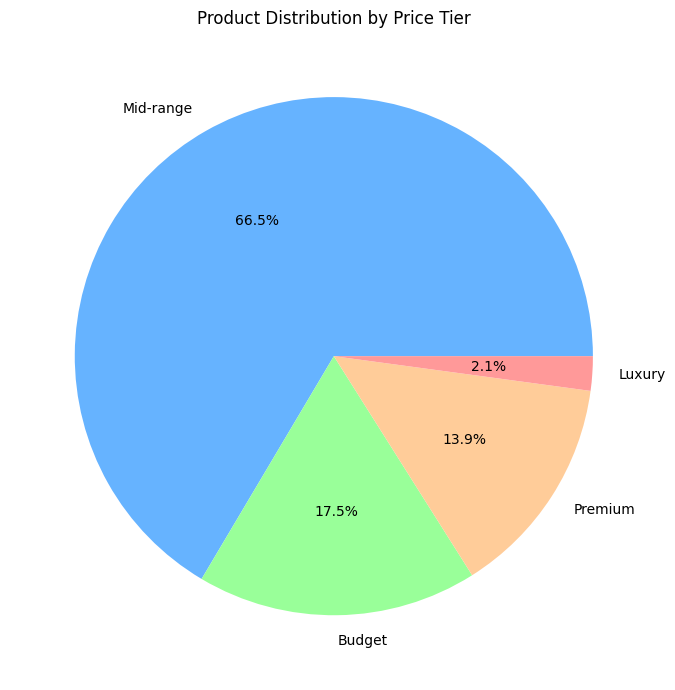

In [35]:
d['PriceTier'] = pd.cut(d['DiscountPrice'],
                          bins=[0, 500, 1500, 3000, np.inf],
                          labels=['Budget', 'Mid-range', 'Premium', 'Luxury'])

plt.figure(figsize=(7,7))
d['PriceTier'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                     colors=['#66b3ff','#99ff99','#ffcc99','#ff9999'])
plt.title('Product Distribution by Price Tier')
plt.ylabel('')
plt.tight_layout()
# plt.savefig('outputs/price_tiers.png')
plt.show()

BrandName
BlissClub                 4.70
V Dot                     4.70
JISORA                    4.60
SHUBHKALA                 4.60
Souchii                   4.60
WEAVERS VILLA             4.60
skyria                    4.60
Dynamocks                 4.58
LOOM LEGACY               4.55
Calvin Klein Underwear    4.55
Name: Ratings, dtype: float64


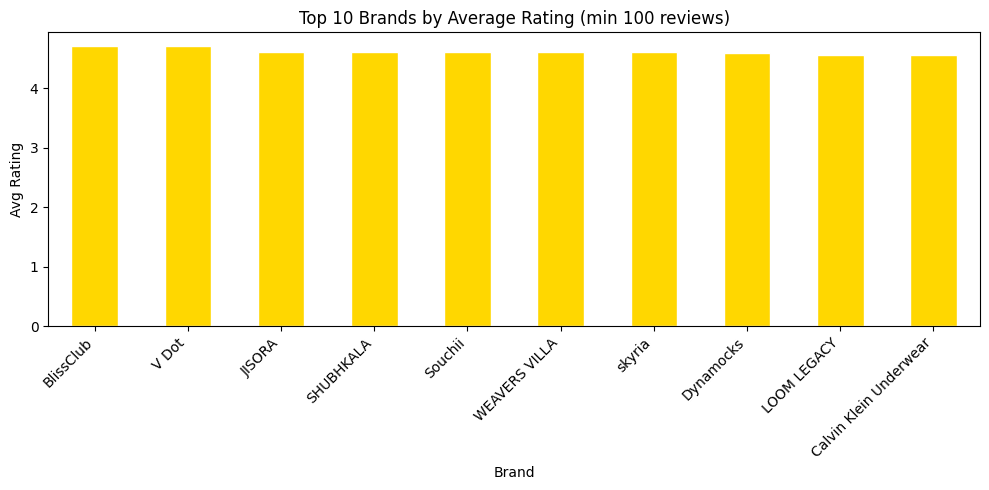

In [36]:
# Minimum 100 reviews for credibility
top_rated_brands = d[d['Reviews'] >= 100]\
    .groupby('BrandName')['Ratings'].mean()\
    .nlargest(10).round(2)

print(top_rated_brands)

top_rated_brands.plot(kind='bar', color='gold', edgecolor='white', figsize=(10,5))
plt.title('Top 10 Brands by Average Rating (min 100 reviews)')
plt.xlabel('Brand')
plt.ylabel('Avg Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('outputs/top_rated_brands.png')
plt.show()

In [37]:
top_products = d.nlargest(10, 'Reviews')[
    ['BrandName', 'Category', 'Individual_category',
     'DiscountPrice', 'Ratings', 'Reviews']
].reset_index(drop=True)

print(top_products.to_string())

               BrandName               Category Individual_category  DiscountPrice  Ratings  Reviews
0               Roadster            Bottom Wear               jeans          824.0      3.9    999.0
1             LOCOMOTIVE            Bottom Wear         track-pants          517.0      4.0    999.0
2               Roadster                Topwear              shirts          629.0      4.3    999.0
3                 Zivame  Lingerie & Sleep Wear           shapewear          893.0      4.2    999.0
4             HIGHLANDER            Bottom Wear            trousers          599.0      3.9    998.0
5  HRX by Hrithik Roshan            Sports Wear              tights         1214.0      4.4    996.0
6              Anubhutee            Indian Wear          kurta-sets         1019.0      4.2    996.0
7             HIGHLANDER                Topwear              shirts          516.0      4.2    995.0
8                Vishudh            Indian Wear              kurtas          696.0      4.2

In [42]:
import sklearn

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features
seg_cols = ['DiscountPrice', 'DiscountPercent', 'Ratings', 'Reviews']
seg_df = d[seg_cols].dropna().copy()

# Scale the data
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_df)

print("Data ready for clustering:", seg_df.shape)

Data ready for clustering: (117565, 4)


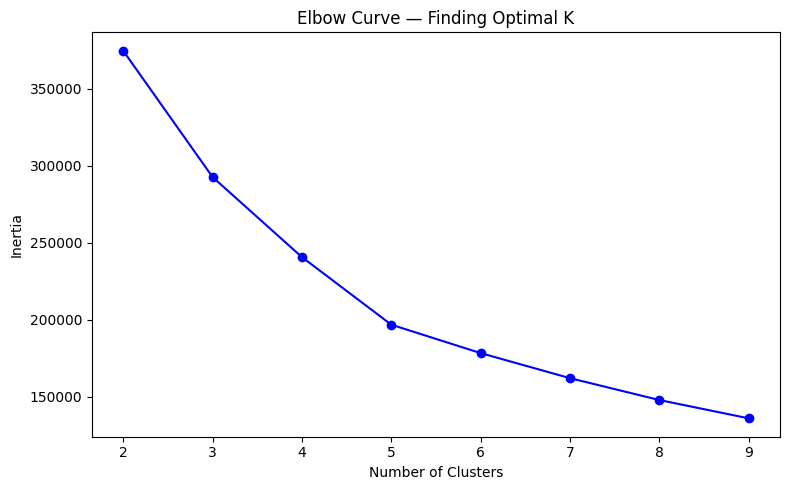

In [44]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 10), inertias, 'bo-')
plt.title('Elbow Curve — Finding Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
# plt.savefig('outputs/elbow_curve.png')
plt.show()

In [46]:

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_df['Cluster'] = km_final.fit_predict(seg_scaled)

# Add cluster back to main dataframe
d.loc[seg_df.index, 'Cluster'] = seg_df['Cluster']

print("Clustering done ✅")
print(seg_df['Cluster'].value_counts())

Clustering done ✅
Cluster
0    60304
2    33100
3    18319
1     5842
Name: count, dtype: int64


In [47]:
cluster_profile = seg_df.groupby('Cluster').mean().round(2)
print(cluster_profile)

         DiscountPrice  DiscountPercent  Ratings  Reviews
Cluster                                                  
0               785.48            59.57     4.21    44.54
1               809.49            54.05     4.10   519.06
2              1506.42            31.56     4.27    33.53
3              1042.92            55.56     3.26    20.40


## Segmentation Findings
- Cluster 0: Budget Deals — cheap, discounted, decent quality
- Cluster 1: Bestsellers — high reviews, Myntra's core revenue drivers
- Cluster 2: Premium Quality — high price, best ratings, low discount
- Cluster 3: Risky Products — poor rating despite heavy discounts, needs review

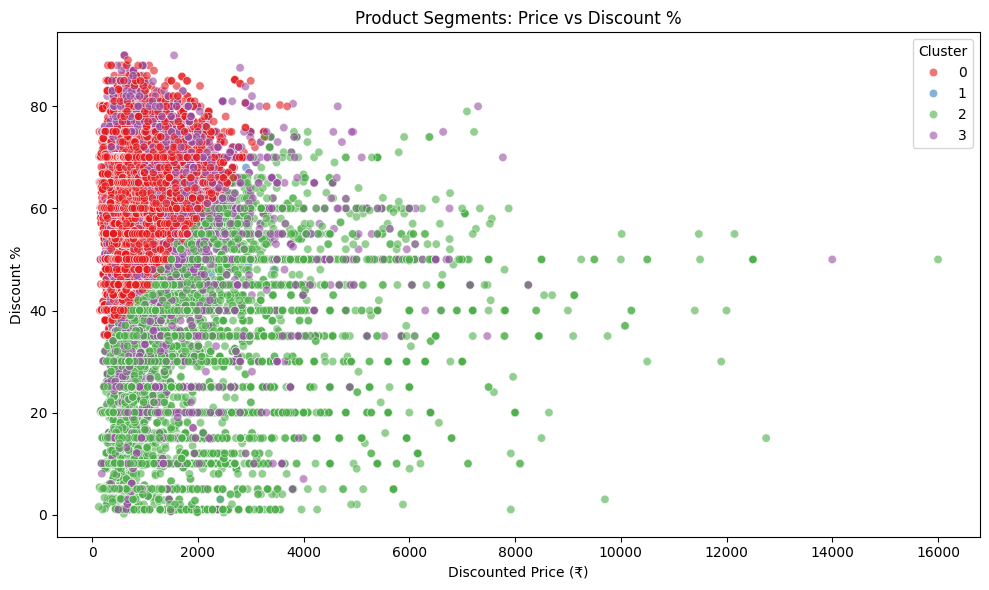

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=seg_df, x='DiscountPrice', y='DiscountPercent',
                hue='Cluster', palette='Set1', alpha=0.6)
plt.title('Product Segments: Price vs Discount %')
plt.xlabel('Discounted Price (₹)')
plt.ylabel('Discount %')
plt.tight_layout()
plt.show()